# Weight Pruning vs Static-Sparse Baselines

Comparing four methods on parallel-MNIST (single hidden layer, ~10 k weights at 2 tasks):

- **Dense** — fully-connected MLP
- **Block-Sparse** — oracle task-aligned blocks
- **Random-Sparse** — uniform random fan-in / fan-out per unit
- **Structure Search** — connection pruning + unit generation (proposed)

Three sweep families:

1. **Stationary** — step-size sweep at `permute_period = 0`, plus a 30-seed best-LR follow-up.
2. **Non-stationary** — same, with `permute_period = 10 000`.
3. **Number-of-tasks scaling** — non-stationary, varying `n_tasks ∈ {2, 4, 8, 16, 32}` with `permute_period = 20000 // n_tasks`. Per-method step-size sweep, best LR chosen per (method, n_tasks).

**Note on the loss.** The training loss is `mean_batch(sum_tasks(NLL_per_class))`, summed across tasks. To keep y-axes comparable across panels we plot `loss / n_tasks` (per-task NLL).

In [1]:
# # Run once to fetch from MLflow. Comment out after first run.
# from phd.research_utils.scripts.mlflow_download import download_experiment
# download_experiment('paper-weight-pruning-sweep', output_dir='data', include_seed_runs=True)
# download_experiment('paper-weight-pruning-best',  output_dir='data', include_seed_runs=True)

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:phd.research_utils.scripts.mlflow_download:Tracking URI: postgresql:///mlflow?host=/var/run/postgresql&port=5433
INFO:phd.research_utils.scripts.mlflow_download:Found experiment 'paper-weight-pruning-sweep' (id=26)
INFO:phd.research_utils.scripts.mlflow_download:Found 1337 runs
INFO:phd.research_utils.scripts.mlflow_download:Discovered 14 metric names from 10 sample runs
INFO:phd.research_utils.scripts.mlflow_download:Metrics to download: ['accuracy', 'accuracy_std', 'active_connections', 'active_units', 'asymptotic_accuracy', 'asymptotic_loss', 'average_loss', 'final_active_connections', 'final_active_units', 'loss', 'loss_std', 'mean_fan_in', 'mean_fan_out', 'path_purity']
Downloading: 100%|██████████| 1337/1337 [01:14

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from phd.research_utils.analysis.analysis_utils import *
from phd.research_utils.analysis.plotting import plot_learning_curves, plot_param_sensitivity

set_matplotlib_style('default')
%matplotlib inline

# Shared palette: Structure Search→blue, Dense→red, Block-Sparse→green,
# Random-Sparse→purple. cb=True selects a color-blind-safe variant.
METHOD_ORDER = ['Dense', 'Block-Sparse', 'Random-Sparse', 'Structure Search']
PALETTE = get_color_palette(classes=METHOD_ORDER)
PALETTE

{'Dense': '#CA3720',
 'Block-Sparse': '#0086DA',
 'Random-Sparse': '#9923DC',
 'Structure Search': '#2BAF2A'}

## Resolve child sweep names

Per-seed child runs only carry a `mlflow.parentRunId` tag — their `sweep_name` falls back to `'default'` in the download. To bucket children correctly, look up each child's parent and copy its `sweep_name` over. The parent map is cached to disk; the cache auto-invalidates when the params CSV is newer.

In [3]:
def resolve_default_sweep_names(params_path, experiment_name, cache_path):
    """Rewrite child rows' sweep_name from 'default' to the parent's sweep_name."""
    df = pd.read_csv(params_path, index_col=0)
    if (df['sweep_name'] == 'default').sum() == 0:
        return
    cache_stale = (
        not os.path.exists(cache_path)
        or os.path.getmtime(cache_path) < os.path.getmtime(params_path)
    )
    if cache_stale:
        import mlflow
        from mlflow.tracking import MlflowClient
        mlflow.set_tracking_uri(os.environ.get('MLFLOW_TRACKING_URI', 'sqlite:///mlruns.db'))
        client = MlflowClient()
        exp = client.get_experiment_by_name(experiment_name)
        all_runs = client.search_runs(experiment_ids=[exp.experiment_id], max_results=50000)
        sweep_by = {r.info.run_id: r.data.tags.get('sweep_name', 'default') for r in all_runs}
        rows = []
        for r in all_runs:
            pid = r.data.tags.get('mlflow.parentRunId')
            if pid:
                rows.append({'run_id': r.info.run_id, 'parent_sweep': sweep_by.get(pid, 'default')})
        pd.DataFrame(rows).to_csv(cache_path, index=False)
        print(f'Refreshed parent map: {cache_path} ({len(rows)} children)')

    map_df = pd.read_csv(cache_path)
    map_dict = dict(zip(map_df['run_id'], map_df['parent_sweep']))
    is_default = df['sweep_name'] == 'default'
    df.loc[is_default, 'sweep_name'] = df.loc[is_default, 'run_id'].map(map_dict).fillna('default')
    df.to_csv(params_path)
    print(f'Resolved {is_default.sum()} child rows in {params_path}')


resolve_default_sweep_names(
    'data/paper_weight_pruning_sweep_params.csv',
    'paper-weight-pruning-sweep',
    'data/sweep_parent_map.csv',
)
resolve_default_sweep_names(
    'data/paper_weight_pruning_best_params.csv',
    'paper-weight-pruning-best',
    'data/best_parent_map.csv',
)

Refreshed parent map: data/sweep_parent_map.csv (1341 children)
Resolved 1050 child rows in data/paper_weight_pruning_sweep_params.csv
Refreshed parent map: data/best_parent_map.csv (372 children)
Resolved 360 child rows in data/paper_weight_pruning_best_params.csv


## Load data and derive `Method`

In [4]:
sweep_cfg, sweep_run = load_experiment_data(
    'data/paper_weight_pruning_sweep_params.csv',
    'data/paper_weight_pruning_sweep_metrics.csv',
)
best_cfg, best_run = load_experiment_data(
    'data/paper_weight_pruning_best_params.csv',
    'data/paper_weight_pruning_best_metrics.csv',
)

def drop_summary_rows(run_dfs):
    for k, rdf in run_dfs.items():
        mask = rdf['loss'].isna() & rdf['asymptotic_loss'].notna()
        run_dfs[k] = rdf[~mask].copy()

drop_summary_rows(sweep_run)
drop_summary_rows(best_run)

print('Sweep buckets:', {k: len(v) for k, v in sweep_cfg.items()})
print('Best buckets :', {k: len(v) for k, v in best_cfg.items()})

Sweep buckets: {'04_block_sparse_bce_lr': 30, '04_single_output_block_sparse_bce_lr': 30, '04_single_output_block_sparse_lr': 42, '03_set_n_tasks': 80, '03_dense_n_tasks': 100, '03_block_sparse_n_tasks': 60, '03_structure_search_n_tasks': 60, '03_random_sparse_n_tasks': 80, '02b_dense_lr': 5, '02b_block_sparse_lr': 5, '02b_structure_search_lr': 4, '02b_random_sparse_lr': 5, '02_block_sparse_lr': 60, '02_dense_lr': 60, '02_structure_search_lr': 60, '02_random_sparse_lr': 60, '01_block_sparse_lr': 60, '01_dense_lr': 60, '01_random_sparse_lr': 60, '01_structure_search_lr': 60}
Best buckets : {'02_block_sparse_best': 31, '01_structure_search_best_dynamic': 31, '01_random_sparse_best_dynamic': 31, '01_block_sparse_best_dynamic': 31, '01_dense_best_dynamic': 31, '02_structure_search_best': 31, '02_random_sparse_best': 31, '02_dense_best': 31, '01_random_sparse_best': 31, '01_structure_search_best': 31, '01_block_sparse_best': 31, '01_dense_best': 31}


In [5]:
def add_method_col(cfg):
    cfg = cfg.copy()
    ss = cfg.get('structure_search.enabled', pd.Series('False', index=cfg.index))
    ss = ss.astype(str).str.lower().eq('true')
    init = cfg.get('model.init_strategy', pd.Series('', index=cfg.index)).astype(str)
    method = pd.Series(index=cfg.index, dtype=object)
    method[ss] = 'Structure Search'
    method[~ss & (init == 'dense')] = 'Dense'
    method[~ss & (init == 'block_sparse')] = 'Block-Sparse'
    method[~ss & (init == 'random_sparse')] = 'Random-Sparse'
    cfg['Method'] = method
    return cfg


def gather(cfg_dfs, run_dfs, sweep_pattern):
    """Pull child runs, add Method, parse numeric LR/n_tasks, add loss_per_task."""
    keys = [k for k in cfg_dfs if sweep_pattern(k)]
    if not keys:
        return pd.DataFrame(), pd.DataFrame()
    cfg = pd.concat([cfg_dfs[k] for k in keys], ignore_index=True)
    run = pd.concat([run_dfs[k] for k in keys], ignore_index=True)
    if 'child_seed' in cfg.columns:
        cfg = cfg[cfg['child_seed'].notna()].copy()
        run = run[run['run_id'].isin(cfg['run_id'])].copy()
    cfg = add_method_col(cfg)
    cfg = cfg[cfg['Method'].notna()].copy()
    run = run[run['run_id'].isin(cfg['run_id'])].copy()
    if 'optimizer.learning_rate' in cfg.columns:
        cfg['optimizer.learning_rate'] = pd.to_numeric(cfg['optimizer.learning_rate'], errors='coerce')
    if 'task.n_tasks' in cfg.columns:
        cfg['task.n_tasks'] = pd.to_numeric(cfg['task.n_tasks'], errors='coerce')
        nt_map = dict(zip(cfg['run_id'], cfg['task.n_tasks']))
        run['loss_per_task'] = run['loss'] / run['run_id'].map(nt_map)
    else:
        run['loss_per_task'] = run['loss']
    return cfg, run


def filter_to_best_lr(cfg, run, group_cols, metric='loss_per_task'):
    """Keep only rows whose LR minimises mean final-5%% `metric` within each group."""
    max_step = run.groupby('run_id')['step'].max()
    thr = (max_step * 0.95).rename('_thr')
    rdf = run.merge(thr, left_on='run_id', right_index=True)
    last5 = rdf[rdf['step'] >= rdf['_thr']]
    metric_per_run = last5.groupby('run_id')[metric].mean().dropna()
    cfg_m = cfg.merge(metric_per_run.rename('_metric'), left_on='run_id', right_index=True)
    grp_lr = cfg_m.groupby(group_cols + ['optimizer.learning_rate'])['_metric'].mean().reset_index()
    best = grp_lr.loc[grp_lr.groupby(group_cols)['_metric'].idxmin()]
    keep_keys = set(map(tuple, best[group_cols + ['optimizer.learning_rate']].values))
    cfg_keys = list(map(tuple, cfg[group_cols + ['optimizer.learning_rate']].values))
    keep_mask = pd.Series([k in keep_keys for k in cfg_keys], index=cfg.index)
    return cfg[keep_mask].copy(), run[run['run_id'].isin(cfg.loc[keep_mask, 'run_id'])].copy(), best

---
## 1. Stationary  (`permute_period = 0`)

### Step-size sensitivity

Stationary sweep: 200 per-seed runs across 4 methods × 10 step-sizes


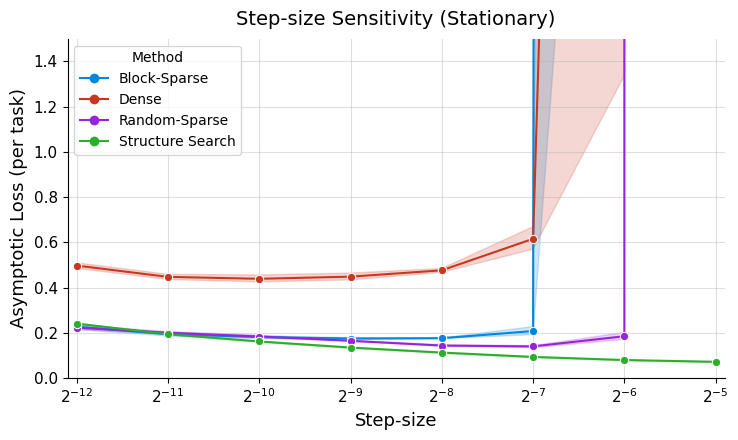

In [6]:
stat_sweep_cfg, stat_sweep_run = gather(
    sweep_cfg, sweep_run,
    sweep_pattern=lambda k: k.startswith('01_') and k.endswith('_lr'),
)
print(f'Stationary sweep: {len(stat_sweep_cfg)} per-seed runs across '
      f'{stat_sweep_cfg["Method"].nunique()} methods × '
      f'{stat_sweep_cfg["optimizer.learning_rate"].nunique()} step-sizes')

plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=stat_sweep_run, config_df=stat_sweep_cfg,
    x_col='optimizer.learning_rate',
    title='Step-size Sensitivity (Stationary)',
    x_label='Step-size', y_label='Asymptotic Loss (per task)',
    metric_col='loss_per_task', metric_type='final_avg',
    hue_col='Method', legend_title='Method', palette=PALETTE,
    show_ci=True, pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.0, 1.5)
plt.tight_layout(); plt.show()

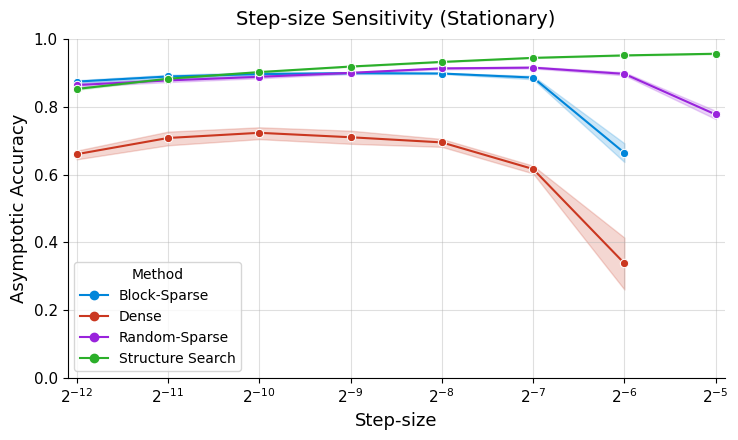

In [7]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=stat_sweep_run, config_df=stat_sweep_cfg,
    x_col='optimizer.learning_rate',
    title='Step-size Sensitivity (Stationary)',
    x_label='Step-size', y_label='Asymptotic Accuracy',
    metric_col='accuracy', metric_type='final_avg',
    hue_col='Method', legend_title='Method', palette=PALETTE,
    show_ci=True, pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.0, 1.0)
plt.tight_layout(); plt.show()

### Learning curves at the best step-size  (30 seeds, 95 % CI)

Stationary best: 120 per-seed runs across 4 methods


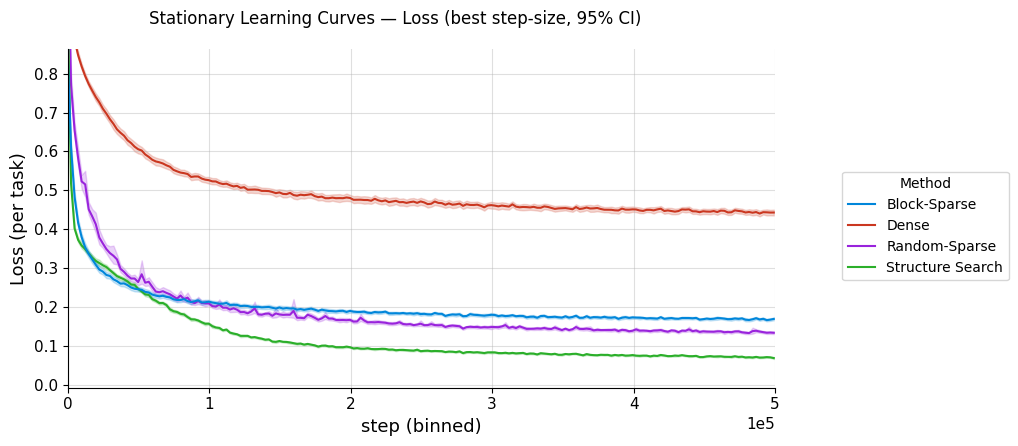

In [8]:
stat_best_cfg, stat_best_run = gather(
    best_cfg, best_run,
    sweep_pattern=lambda k: k.startswith('01_') and k.endswith('_best'),
)
print(f'Stationary best: {len(stat_best_cfg)} per-seed runs across '
      f'{stat_best_cfg["Method"].nunique()} methods')

plot_learning_curves(
    run_df=stat_best_run, config_df=stat_best_cfg,
    n_bins=200, figsize=(8, 4.5),
    y_col='loss_per_task', y_label='Loss (per task)',
    hue_col='Method', legend_title='Method', palette=PALETTE, show_ci=True,
)
plt.suptitle('Stationary Learning Curves — Loss (best step-size, 95% CI)')
plt.tight_layout(); plt.show()

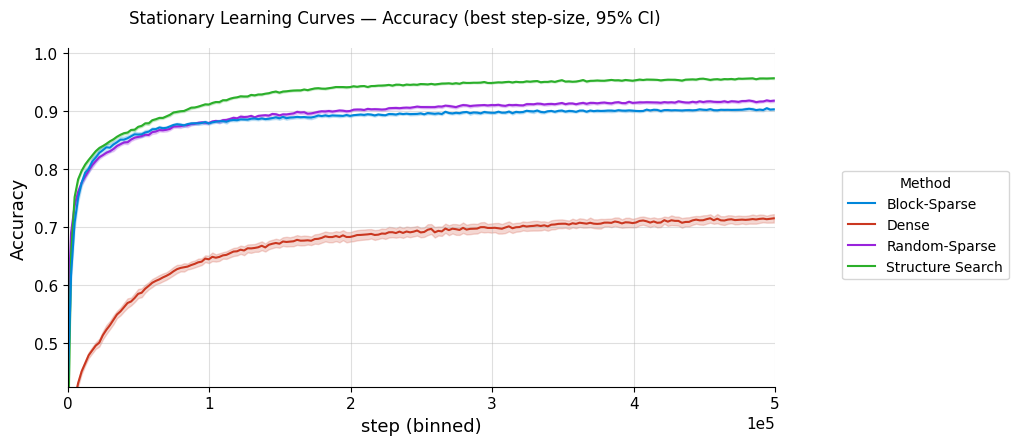

In [9]:
plot_learning_curves(
    run_df=stat_best_run, config_df=stat_best_cfg,
    n_bins=200, figsize=(8, 4.5),
    y_col='accuracy', y_label='Accuracy',
    hue_col='Method', legend_title='Method', palette=PALETTE, show_ci=True,
)
plt.suptitle('Stationary Learning Curves — Accuracy (best step-size, 95% CI)')
plt.tight_layout(); plt.show()

---
## 2. Non-Stationary  (`permute_period = 10 000`)

### Step-size sensitivity

Non-stationary sweep: 200 per-seed runs across 4 methods


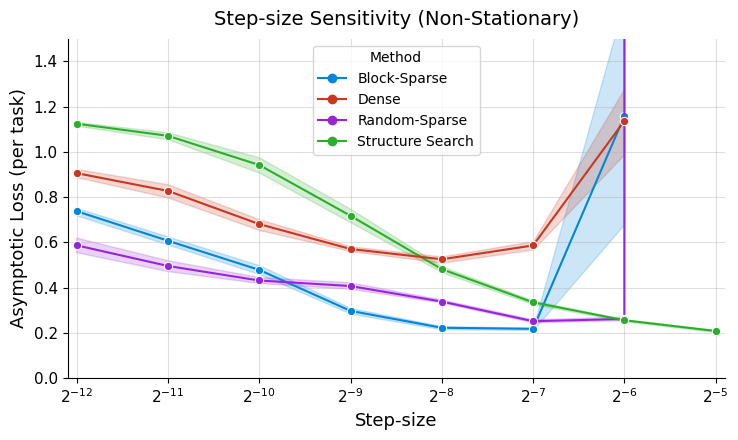

In [10]:
ns_sweep_cfg, ns_sweep_run = gather(
    sweep_cfg, sweep_run,
    sweep_pattern=lambda k: k.startswith('02_') and k.endswith('_lr'),
)
print(f'Non-stationary sweep: {len(ns_sweep_cfg)} per-seed runs across '
      f'{ns_sweep_cfg["Method"].nunique() if len(ns_sweep_cfg) else 0} methods')

if len(ns_sweep_cfg):
    plt.figure(figsize=(7.5, 4.5))
    plot_param_sensitivity(
        run_df=ns_sweep_run, config_df=ns_sweep_cfg,
        x_col='optimizer.learning_rate',
        title='Step-size Sensitivity (Non-Stationary)',
        x_label='Step-size', y_label='Asymptotic Loss (per task)',
        metric_col='loss_per_task', metric_type='final_avg',
        hue_col='Method', legend_title='Method', palette=PALETTE,
        show_ci=True, pow_2_x_axis=True, nan_policy='omit',
    )
    plt.ylim(0.0, 1.5)
    plt.tight_layout(); plt.show()
else:
    print('No non-stationary sweep data yet.')

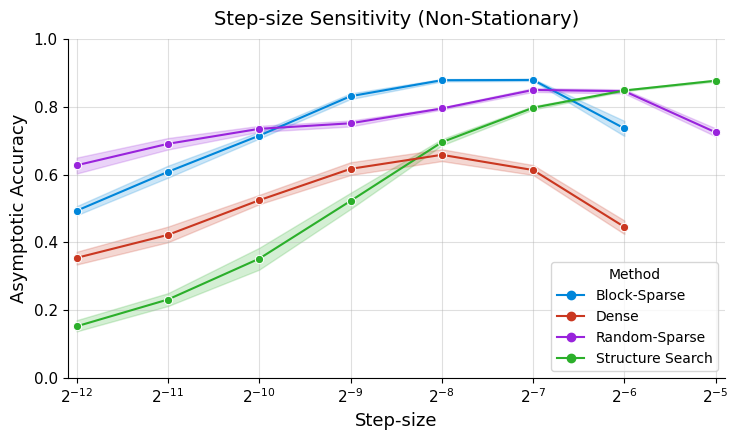

In [11]:
if len(ns_sweep_cfg):
    plt.figure(figsize=(7.5, 4.5))
    plot_param_sensitivity(
        run_df=ns_sweep_run, config_df=ns_sweep_cfg,
        x_col='optimizer.learning_rate',
        title='Step-size Sensitivity (Non-Stationary)',
        x_label='Step-size', y_label='Asymptotic Accuracy',
        metric_col='accuracy', metric_type='final_avg',
        hue_col='Method', legend_title='Method', palette=PALETTE,
        show_ci=True, pow_2_x_axis=True, nan_policy='omit',
    )
    plt.ylim(0.0, 1.0)
    plt.tight_layout(); plt.show()

### Learning curves at the best step-size  (30 seeds, 95 % CI)

Non-stationary best: 120 per-seed runs across 4 methods


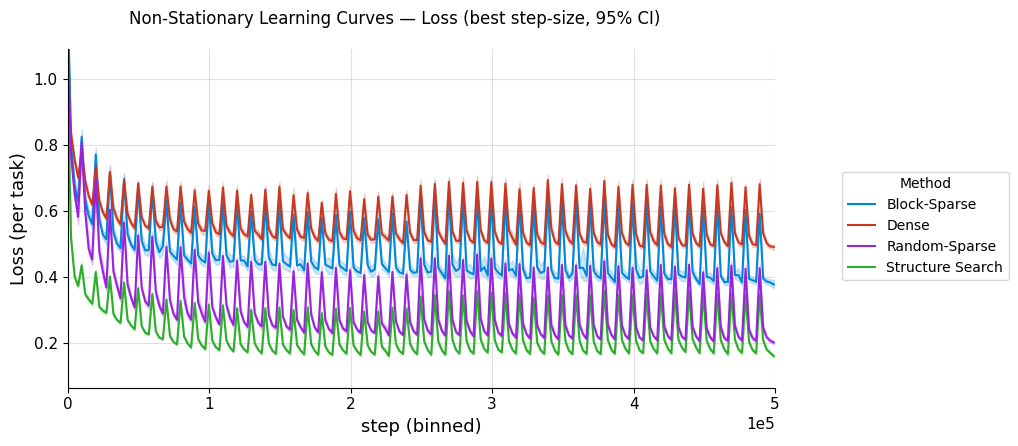

In [12]:
ns_best_cfg, ns_best_run = gather(
    best_cfg, best_run,
    sweep_pattern=lambda k: k.startswith('02_') and k.endswith('_best'),
)
print(f'Non-stationary best: {len(ns_best_cfg)} per-seed runs across '
      f'{ns_best_cfg["Method"].nunique() if len(ns_best_cfg) else 0} methods')

if len(ns_best_cfg):
    plot_learning_curves(
        run_df=ns_best_run, config_df=ns_best_cfg,
        n_bins=200, figsize=(8, 4.5),
        y_col='loss_per_task', y_label='Loss (per task)',
        hue_col='Method', legend_title='Method', palette=PALETTE, show_ci=True,
    )
    plt.suptitle('Non-Stationary Learning Curves — Loss (best step-size, 95% CI)')
    plt.tight_layout(); plt.show()
else:
    print('No non-stationary best data yet.')

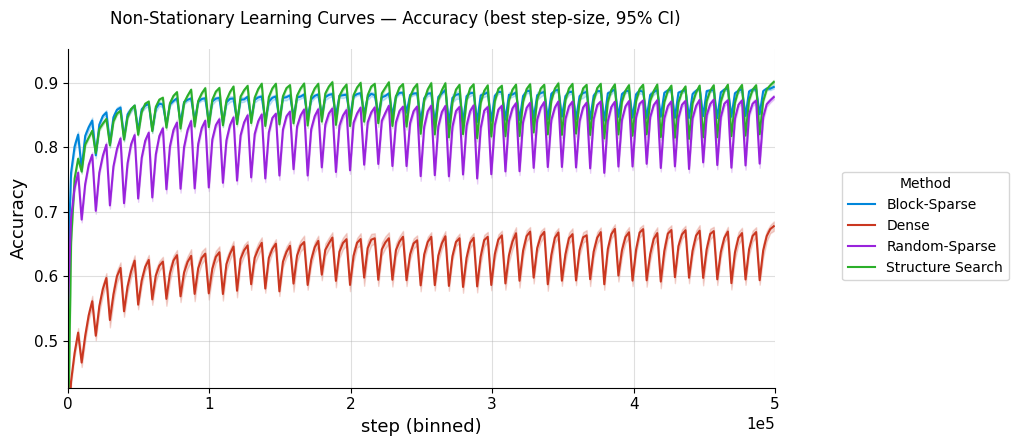

In [13]:
if len(ns_best_cfg):
    plot_learning_curves(
        run_df=ns_best_run, config_df=ns_best_cfg,
        n_bins=200, figsize=(8, 4.5),
        y_col='accuracy', y_label='Accuracy',
        hue_col='Method', legend_title='Method', palette=PALETTE, show_ci=True,
    )
    plt.suptitle('Non-Stationary Learning Curves — Accuracy (best step-size, 95% CI)')
    plt.tight_layout(); plt.show()

---
## 3. Number-of-tasks scaling  (non-stationary, `permute_period = 20000 / n_tasks`)

Step-size is swept per (method, n_tasks); for each cell the LR with the lowest mean final-5 % per-task loss is kept.

### Sensitivity to number of tasks (best step-size per cell)

In [14]:
nt_cfg, nt_run = gather(
    sweep_cfg, sweep_run,
    sweep_pattern=lambda k: k.startswith('03_') and k.endswith('_n_tasks'),
)
print(f'n_tasks sweep: {len(nt_cfg)} per-seed runs across '
      f'{nt_cfg["Method"].nunique() if len(nt_cfg) else 0} methods × '
      f'{nt_cfg["task.n_tasks"].nunique() if len(nt_cfg) else 0} n_tasks values')

if len(nt_cfg):
    nt_best_cfg, nt_best_run, nt_best_lrs = filter_to_best_lr(
        nt_cfg, nt_run, group_cols=['Method', 'task.n_tasks'],
    )
    chosen = (nt_best_lrs[['Method', 'task.n_tasks', 'optimizer.learning_rate', '_metric']]
              .rename(columns={'_metric': 'mean_per_task_loss'}))
    chosen['lr_pow2'] = chosen['optimizer.learning_rate'].map(
        lambda x: f'2^{int(np.round(np.log2(x)))}' if x > 0 else '0'
    )
    print('Chosen step-sizes:')
    print(chosen.sort_values(['Method', 'task.n_tasks']).to_string(index=False))

n_tasks sweep: 225 per-seed runs across 4 methods × 5 n_tasks values
Chosen step-sizes:
          Method  task.n_tasks  optimizer.learning_rate  mean_per_task_loss lr_pow2
    Block-Sparse           2.0                 0.001953            0.446627    2^-9
    Block-Sparse           4.0                 0.003906            0.447960    2^-8
    Block-Sparse           8.0                 0.003906            0.454405    2^-8
    Block-Sparse          16.0                 0.003906            0.449300    2^-8
    Block-Sparse          32.0                 0.003906            0.461214    2^-8
           Dense           2.0                 0.001953            1.029054    2^-9
           Dense           4.0                 0.000977            1.718809   2^-10
           Dense           8.0                 0.000977            2.050136   2^-10
           Dense          16.0                 0.000488            2.178794   2^-11
           Dense          32.0                 0.000244            2.258

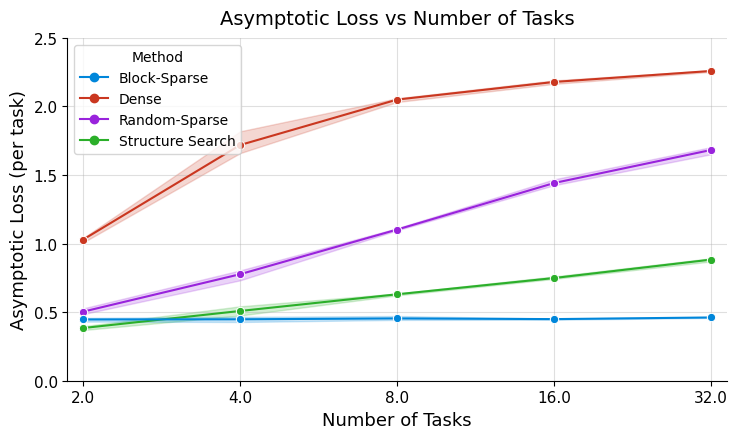

In [15]:
if len(nt_cfg):
    plt.figure(figsize=(7.5, 4.5))
    plot_param_sensitivity(
        run_df=nt_best_run, config_df=nt_best_cfg,
        x_col='task.n_tasks',
        title='Asymptotic Loss vs Number of Tasks',
        x_label='Number of Tasks', y_label='Asymptotic Loss (per task)',
        metric_col='loss_per_task', metric_type='final_avg',
        hue_col='Method', legend_title='Method', palette=PALETTE,
        show_ci=True, nan_policy='omit',
    )
    plt.ylim(0.0, 2.5)
    plt.tight_layout(); plt.show()

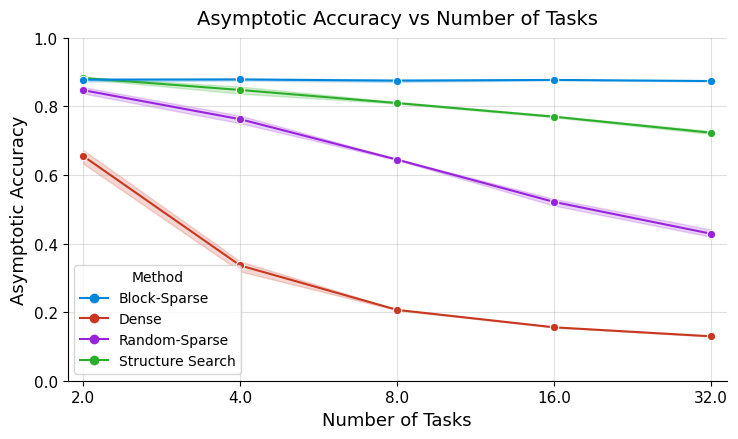

In [16]:
if len(nt_cfg):
    plt.figure(figsize=(7.5, 4.5))
    plot_param_sensitivity(
        run_df=nt_best_run, config_df=nt_best_cfg,
        x_col='task.n_tasks',
        title='Asymptotic Accuracy vs Number of Tasks',
        x_label='Number of Tasks', y_label='Asymptotic Accuracy',
        metric_col='accuracy', metric_type='final_avg',
        hue_col='Method', legend_title='Method', palette=PALETTE,
        show_ci=True, nan_policy='omit',
    )
    plt.ylim(0.0, 1.0)
    plt.tight_layout(); plt.show()

### Learning curves at `n_tasks = 32`  (best step-size per method, 95 % CI)

n_tasks=32: 12 per-seed runs


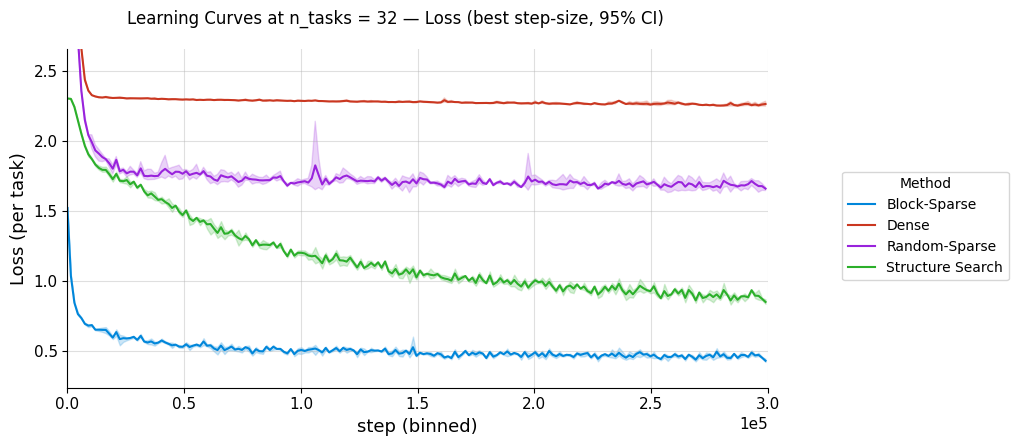

In [17]:
if len(nt_cfg):
    nt32_cfg = nt_best_cfg[nt_best_cfg['task.n_tasks'] == 32].copy()
    nt32_run = nt_best_run[nt_best_run['run_id'].isin(nt32_cfg['run_id'])].copy()
    print(f'n_tasks=32: {len(nt32_cfg)} per-seed runs')

    if len(nt32_cfg):
        plot_learning_curves(
            run_df=nt32_run, config_df=nt32_cfg,
            n_bins=200, figsize=(8, 4.5),
            y_col='loss_per_task', y_label='Loss (per task)',
            hue_col='Method', legend_title='Method', palette=PALETTE, show_ci=True,
        )
        plt.suptitle('Learning Curves at n_tasks = 32 — Loss (best step-size, 95% CI)')
        plt.tight_layout(); plt.show()
    else:
        print('No n_tasks=32 data yet.')

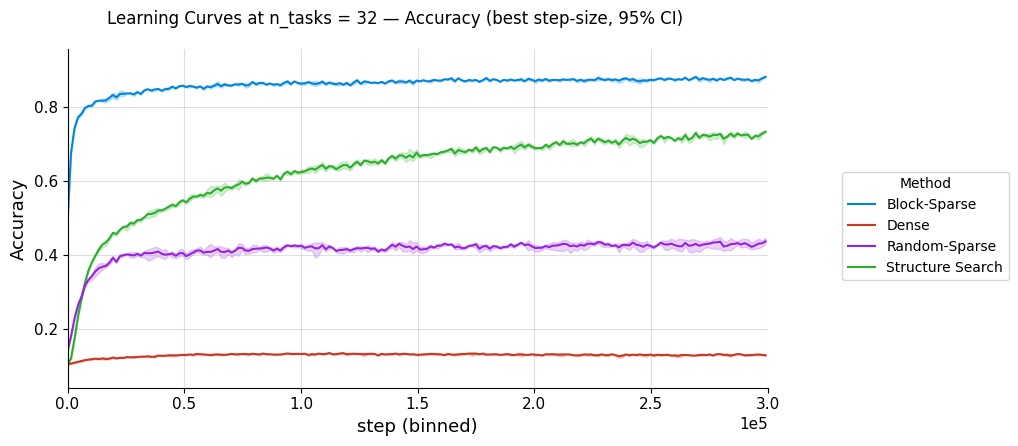

In [18]:
if len(nt_cfg) and len(nt32_cfg):
    plot_learning_curves(
        run_df=nt32_run, config_df=nt32_cfg,
        n_bins=200, figsize=(8, 4.5),
        y_col='accuracy', y_label='Accuracy',
        hue_col='Method', legend_title='Method', palette=PALETTE, show_ci=True,
    )
    plt.suptitle('Learning Curves at n_tasks = 32 — Accuracy (best step-size, 95% CI)')
    plt.tight_layout(); plt.show()